In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np

from shapely.geometry import box
from pathlib import Path

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
ROOT = Path("/content/drive/MyDrive/turkiye-border-wellbeing")

RAW_BOUNDARIES = ROOT / "data/raw/boundaries"
INTERIM = ROOT / "data/interim"

INTERIM.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Interim folder:", INTERIM)

Project root: /content/drive/MyDrive/turkiye-border-wellbeing
Interim folder: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim


In [4]:
study_area = gpd.read_file(
    RAW_BOUNDARIES / "study_area_adm1_raw.gpkg"
)

print("CRS:", study_area.crs)
print(study_area[["ADM0_NAME", "ADM1_NAME"]])

CRS: EPSG:4326
  ADM0_NAME   ADM1_NAME
0    Turkey      Edirne
1    Turkey  Kirklareli
2    Turkey    Tekirdag


In [5]:
study_union = study_area.dissolve()

print("Study area features:", len(study_union))

Study area features: 1


In [6]:
study_utm = study_union.to_crs("EPSG:32635")

print("Projected CRS:", study_utm.crs)

Projected CRS: EPSG:32635


In [7]:
study_area_km2 = study_utm.geometry.area.iloc[0] / 1_000_000

print(f"Study area: {study_area_km2:,.2f} km²")

Study area: 19,000.65 km²


In [8]:
minx, miny, maxx, maxy = study_utm.total_bounds

cell_size = 1000  # meters

x_coords = np.arange(
    np.floor(minx / cell_size) * cell_size,
    np.ceil(maxx / cell_size) * cell_size,
    cell_size
)

y_coords = np.arange(
    np.floor(miny / cell_size) * cell_size,
    np.ceil(maxy / cell_size) * cell_size,
    cell_size
)

cells = []

for x in x_coords:
    for y in y_coords:
        cells.append(
            box(
                x,
                y,
                x + cell_size,
                y + cell_size
            )
        )

grid_all = gpd.GeoDataFrame(
    geometry=cells,
    crs="EPSG:32635"
)

print("Initial rectangular grid cells:", len(grid_all))

Initial rectangular grid cells: 31992


In [9]:
study_geom = study_utm.geometry.iloc[0]

grid_intersect = grid_all[
    grid_all.intersects(study_geom)
].copy()

print("Cells intersecting study area:", len(grid_intersect))

Cells intersecting study area: 19501


In [10]:
grid_intersect["full_area_m2"] = (
    grid_intersect.geometry.area
)

grid_intersect["inside_area_m2"] = (
    grid_intersect.geometry.intersection(
        study_geom
    ).area
)

grid_intersect["inside_share"] = (
    grid_intersect["inside_area_m2"] /
    grid_intersect["full_area_m2"]
)

In [11]:
print(
    grid_intersect["inside_share"].describe()
)

count    19501.000000
mean         0.974342
std          0.135889
min          0.000012
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: inside_share, dtype: float64


In [12]:
grid_main = grid_intersect[
    grid_intersect["inside_share"] >= 0.50
].copy()

grid_main = grid_main.reset_index(drop=True)

print("Main 1x1 km grid cells:", len(grid_main))

Main 1x1 km grid cells: 18994


In [13]:
print(
    "Excluded boundary cells:",
    len(grid_intersect) - len(grid_main)
)

print(
    "Retention rate:",
    round(len(grid_main) / len(grid_intersect) * 100, 2),
    "%"
)

Excluded boundary cells: 507
Retention rate: 97.4 %


In [14]:
centroids_temp = grid_intersect.copy()
centroids_temp["geometry"] = centroids_temp.geometry.centroid

centroid_inside = centroids_temp.within(study_geom)

grid_centroid_rule = grid_intersect[
    centroid_inside
].copy()

print("Centroid-rule grid cells:", len(grid_centroid_rule))
print("50% rule grid cells:", len(grid_main))
print(
    "Difference:",
    len(grid_centroid_rule) - len(grid_main)
)

Centroid-rule grid cells: 19001
50% rule grid cells: 18994
Difference: 7


In [15]:
centroids_temp = grid_intersect.copy()
centroids_temp["geometry"] = centroids_temp.geometry.centroid

centroid_inside = centroids_temp.within(study_geom)

grid_main = grid_intersect[
    centroid_inside
].copy()

grid_main = grid_main.reset_index(drop=True)

print("Final main grid cells:", len(grid_main))

Final main grid cells: 19001


In [16]:
grid_50 = grid_intersect[
    grid_intersect["inside_share"] >= 0.50
].copy()

grid_50 = grid_50.reset_index(drop=True)

print("Robustness grid cells:", len(grid_50))

Robustness grid cells: 18994


In [17]:
grid_main["grid_id"] = [
    f"G{i:06d}"
    for i in range(1, len(grid_main) + 1)
]

grid_main["cell_area_km2"] = (
    grid_main.geometry.area / 1_000_000
)

grid_main["inside_area_km2"] = (
    grid_main["inside_area_m2"] / 1_000_000
)

In [18]:
adm2 = gpd.read_file(
    RAW_BOUNDARIES / "study_area_adm2_raw.gpkg"
)

adm2_utm = adm2.to_crs("EPSG:32635")

print("ADM2 districts:", len(adm2_utm))

ADM2 districts: 26


In [19]:
grid_centroids = grid_main[
    ["grid_id", "geometry"]
].copy()

grid_centroids["geometry"] = (
    grid_centroids.geometry.centroid
)

In [20]:
grid_admin = gpd.sjoin(
    grid_centroids,
    adm2_utm[
        [
            "ADM1_NAME",
            "ADM2_NAME",
            "district_id",
            "geometry"
        ]
    ],
    how="left",
    predicate="within"
)

In [21]:
print(
    grid_admin[
        [
            "grid_id",
            "ADM1_NAME",
            "ADM2_NAME",
            "district_id"
        ]
    ].head(10)
)

   grid_id ADM1_NAME ADM2_NAME  district_id
0  G000001    Edirne      Enez  Edirne_Enez
1  G000002    Edirne      Enez  Edirne_Enez
2  G000003    Edirne      Enez  Edirne_Enez
3  G000004    Edirne      Enez  Edirne_Enez
4  G000005    Edirne      Enez  Edirne_Enez
5  G000006    Edirne      Enez  Edirne_Enez
6  G000007    Edirne      Enez  Edirne_Enez
7  G000008    Edirne      Enez  Edirne_Enez
8  G000009    Edirne      Enez  Edirne_Enez
9  G000010    Edirne      Enez  Edirne_Enez


In [22]:
admin_lookup = (
    grid_admin[
        [
            "grid_id",
            "ADM1_NAME",
            "ADM2_NAME",
            "district_id"
        ]
    ]
    .drop_duplicates(subset="grid_id")
)

grid_main = grid_main.merge(
    admin_lookup,
    on="grid_id",
    how="left"
)

grid_main = grid_main.rename(
    columns={
        "ADM1_NAME": "province",
        "ADM2_NAME": "district"
    }
)

In [23]:
print("Missing province:",
      grid_main["province"].isna().sum())

print("Missing district:",
      grid_main["district"].isna().sum())

Missing province: 0
Missing district: 0


In [24]:
grid_main["centroid_x"] = (
    grid_main.geometry.centroid.x
)

grid_main["centroid_y"] = (
    grid_main.geometry.centroid.y
)

In [26]:
centroids_wgs84 = grid_centroids.to_crs("EPSG:4326")

coord_lookup = pd.DataFrame({
    "grid_id": centroids_wgs84["grid_id"].values,
    "longitude": centroids_wgs84.geometry.x.values,
    "latitude": centroids_wgs84.geometry.y.values
})

grid_main = grid_main.merge(
    coord_lookup,
    on="grid_id",
    how="left"
)

In [27]:
print(grid_main.columns.tolist())

['geometry', 'full_area_m2', 'inside_area_m2', 'inside_share', 'grid_id', 'cell_area_km2', 'inside_area_km2', 'province', 'district', 'district_id', 'centroid_x', 'centroid_y', 'longitude', 'latitude']


In [28]:
print(
    grid_main[
        [
            "grid_id",
            "province",
            "district",
            "district_id",
            "inside_share",
            "longitude",
            "latitude"
        ]
    ].head()
)

   grid_id province district  district_id  inside_share  longitude   latitude
0  G000001   Edirne     Enez  Edirne_Enez      0.890126  26.046674  40.732502
1  G000002   Edirne     Enez  Edirne_Enez      0.600805  26.046545  40.741510
2  G000003   Edirne     Enez  Edirne_Enez      0.616559  26.058769  40.714585
3  G000004   Edirne     Enez  Edirne_Enez      0.879834  26.058642  40.723592
4  G000005   Edirne     Enez  Edirne_Enez      1.000000  26.058515  40.732600


In [29]:
print("Missing province:",
      grid_main["province"].isna().sum())

print("Missing district:",
      grid_main["district"].isna().sum())

print("Missing longitude:",
      grid_main["longitude"].isna().sum())

print("Missing latitude:",
      grid_main["latitude"].isna().sum())

Missing province: 0
Missing district: 0
Missing longitude: 0
Missing latitude: 0


In [30]:
print(
    grid_main["province"]
    .value_counts()
    .sort_index()
)

province
Edirne        6193
Kirklareli    6575
Tekirdag      6233
Name: count, dtype: int64


In [31]:
grid_gpkg = INTERIM / "grid_1km_master.gpkg"

grid_main.to_file(
    grid_gpkg,
    layer="grid_1km",
    driver="GPKG"
)

print("Saved:", grid_gpkg)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/grid_1km_master.gpkg


In [32]:
grid_csv = INTERIM / "grid_1km_attributes.csv"

grid_main.drop(columns="geometry").to_csv(
    grid_csv,
    index=False
)

print("Saved:", grid_csv)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/grid_1km_attributes.csv


In [33]:
grid_50 = grid_intersect[
    grid_intersect["inside_share"] >= 0.50
].copy().reset_index(drop=True)

grid_50["grid_id"] = [
    f"R{i:06d}"
    for i in range(1, len(grid_50) + 1)
]

grid_50_path = INTERIM / "grid_1km_robustness_50pct.gpkg"

grid_50.to_file(
    grid_50_path,
    layer="grid_1km_50pct",
    driver="GPKG"
)

print("Saved:", grid_50_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/grid_1km_robustness_50pct.gpkg


In [34]:
import json

grid_metadata = {
    "main_grid_resolution": "1000 m x 1000 m",
    "main_inclusion_rule":
        "Grid centroid located within the study-area boundary",
    "main_grid_count": 19001,
    "robustness_rule":
        "At least 50 percent of grid-cell area located within the study area",
    "robustness_grid_count": 18994,
    "difference_in_grid_count": 7,
    "projected_crs": "EPSG:32635",
    "geographic_crs": "EPSG:4326",
    "study_provinces": [
        "Edirne",
        "Kirklareli",
        "Tekirdag"
    ],
    "province_grid_counts": {
        "Edirne": 6193,
        "Kirklareli": 6575,
        "Tekirdag": 6233
    }
}

metadata_path = INTERIM / "grid_1km_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(grid_metadata, f, indent=4, ensure_ascii=False)

print("Saved:", metadata_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/grid_1km_metadata.json


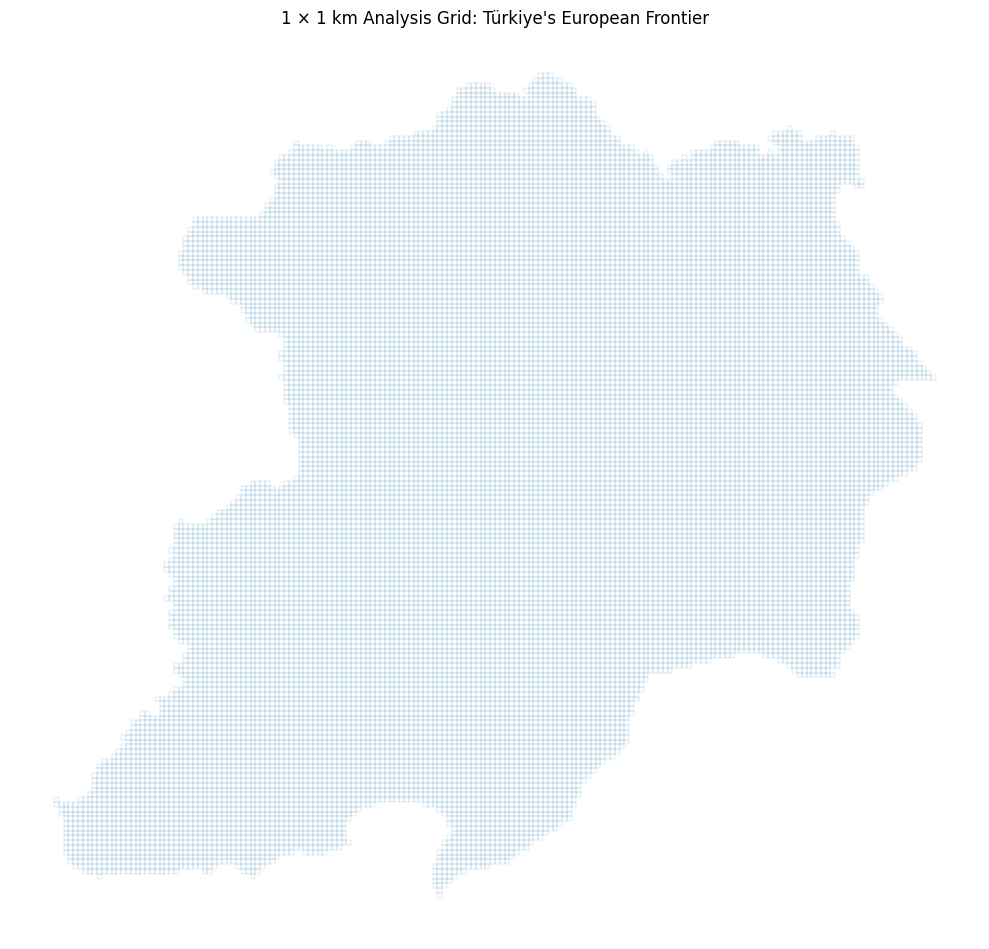

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/figures/appendix/qc_grid_1km.png


In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

study_utm.boundary.plot(
    ax=ax,
    linewidth=1.2
)

grid_main.boundary.plot(
    ax=ax,
    linewidth=0.10
)

ax.set_title(
    "1 × 1 km Analysis Grid: Türkiye's European Frontier"
)

ax.set_axis_off()

plt.tight_layout()

qc_path = ROOT / "figures" / "appendix" / "qc_grid_1km.png"
qc_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    qc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", qc_path)